In [1]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'GPU: Tesla T4'

In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_token = user_secrets.get_secret("pfn_key")

USE_PFN_TOKEN = True
RUN_LOCAL     = True

if RUN_LOCAL:
    print("Loading tabpfn_local... ")
    os.environ["TABPFN_MODEL_CACHE_DIR"] = "/kaggle/input/models/prior-labsai/tabpfn-3-5/pytorch/default/1"
    try:
        from tabpfn import TabPFNClassifier
    except:
        !uv pip install tabpfn
        from tabpfn import TabPFNClassifier
    ## -----------------------------------------------------
    # if USE_PFN_TOKEN: # Option 1: Use secret token key
    #     os.environ["TABPFN_TOKEN"] = secret_token
    # else: # Option 2: Access to direct model
    #     os.environ["TABPFN_MODEL_CACHE_DIR"] = "/kaggle/input/models/prior-labsai/tabpfn-3-5/pytorch/default/1"
    print("Complete!")
else:
    print("Connecting tabpfn_client... ", end='')
    try:
        import tabpfn_client
        from tabpfn_client import TabPFNClassifier, set_access_token, get_api_usage
    except:
        !uv pip install tabpfn-client
        import tabpfn_client
        from tabpfn_client import TabPFNClassifier, set_access_token, get_api_usage
    tabpfn_client.set_access_token(secret_token)

    print("Complete!")
    print(get_api_usage())

Loading tabpfn_local... 
Using Python 3.12.13 environment at: /usr
Resolved 80 packages in 1.41s
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
⠙ Preparing packages... (0/2)
skrub                ------------------------------     0 B/581.95 KiB
⠙ Preparing packages... (0/2)
skrub                ------------------------------ 14.06 KiB/581.95 KiB
⠙ Preparing packages... (0/2)
skrub                ------------------------------ 14.06 KiB/581.95 KiB
⠙ Preparing packages... (0/2)
skrub                ------------------------------ 30.06 KiB/581.95 KiB
⠙ Preparing packages... (0/2)
skrub                ------------------------------ 30.06 KiB/581.95 KiB
⠙ Preparing packages... (0/2)
skrub                ------------------------------ 30.06 KiB/581.95 KiB
⠙ Preparing packa

In [3]:
## -- Data Manipulation -- 
import numpy as np, pandas as pd, random
from scipy.optimize import minimize

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm import tqdm
import itertools

## -- Machine Learning --
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, log_loss, RocCurveDisplay
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, TargetEncoder as skTE

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [4]:
## -- Global Settings --
# sklearn.set_config(transform_output='pandas')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 100)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS':   5,
    'SEED':    42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RESET':  '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --

PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e9/"
    submission = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/"
    orig = pd.read_csv(ORIG_PATH+"EV_Adoption_and_Range_Anxiety_Dataset.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/"
    submission = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

## =================================================================================

ID     = "id"
TARGET = 'Will_Buy_EV'

obj = train.select_dtypes(include=["object", "category"]).columns.tolist()

cat_cols  = [c for c in obj if c not in [TARGET, ID]]
num_cols  = [c for c in train.columns if c not in cat_cols+[TARGET, ID]]
base_cols = cat_cols + num_cols

train[TARGET] = train[TARGET].map({'No': 0, 'Yes': 1})
orig[TARGET]  = orig[TARGET].map({'No': 0, 'Yes': 1})

FEATURES = [c for c in train.columns if c not in [ID, TARGET]]

orig = orig[FEATURES+[TARGET]]
print("Total Features:", len(FEATURES))

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Nums: {len(num_cols)}")
print(f"Total Cats: {len(cat_cols)}")
print(f"Total base: {len(base_cols)}")

Total Features: 13
Train shape: (668665, 15)
Test shape: (286571, 14)
Orig shape: (10000, 14)

Total Nums: 7
Total Cats: 6
Total base: 13


In [6]:
for c in num_cols:
    orig[c] = orig[c].fillna(orig[c].median())

orig.isna().sum() 

Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64

In [7]:
n_unique = train[base_cols].nunique().sort_values()
n_unique

Home_Charging_Possible             2
Subsidy_Available                  2
City_Type                          3
Gender                             3
Range_Anxiety_Level                3
Current_Car_Type                   4
Number_of_Cars_Owned               4
Environmental_Concern_Level        5
Charging_Stations_Near_Home       15
Charging_Stations_Near_Work       20
Age                               45
Daily_Commute_km                 805
Annual_Income_USD              13214
dtype: int64

In [8]:
def get_class_weights(y):
    """
    y: Current y_labels -> array_like or series
    """
    wts = compute_class_weight('balanced', classes=np.unique(y), y=y)
    return wts

def get_sample_weights(y, y_true):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    """
    cls = np.unique(y_true)
    wts = compute_class_weight('balanced', classes=cls, y=y_true)
    class_weights = dict(zip(cls, wts))
    return np.array([class_weights[label] for label in y])

print('- Helper Functions Ready -')

- Helper Functions Ready -


## FEATURE ENGINEERING

In [9]:
# def feat_eng(df1, trn=True):
#     df = df1.copy()
#     # Arithmetic interaction
#     df['_Daily_Commute_km_/_Age'] = (df['Daily_Commute_km'] / (df['Age'] + 1)).astype('float32')

#     df['Income_//_10_cat'] = (df['Annual_Income_USD'] // 10).astype('float32')
#     df['Income_//_100_cat'] = (df['Annual_Income_USD'] // 100).astype('float32')
#     df['Income_//_1000_cat'] = (df['Annual_Income_USD'] // 1000).astype('float32')
#     # df['gt_179k_lock'] = (df['Annual_Income_USD'] >= 179_000).astype('int8')

#     log_cols = []
#     for col in ['Annual_Income_USD', 'Daily_Commute_km']:
#         log_name = f"_log_{col}"
#         df[log_name] = np.log(df[col])
#         log_cols.append(log_name)

#     nm_cols = log_cols + ['_Daily_Commute_km_/_Age']
#     ct_cols = ['Income_//_10_cat', 'Income_//_100_cat', 'Income_//_1000_cat'] #[] 

#     if trn:
#         return df, nm_cols, ct_cols
#     else:
#         return df

# train, nm_cols, ct_cols = feat_eng(train)
# test = feat_eng(test, trn=False)
# orig = feat_eng(orig, trn=False)

# num_cols = list(set(num_cols + nm_cols))
# # cat_cols = list(set(cat_cols + ct_cols))

# train

In [10]:
def feat_eng(df1):
    df = df1.copy()

    # Arithmetic interaction
    df['_Daily_Commute_km_/_Age'] = (df['Daily_Commute_km'] / (df['Age'] + 1)).astype('float32')
    # df['Income_/_100_floor_'] = np.floor(df['Annual_Income_USD'] / 100.0).astype('float32').astype('category')
    # df['Income_/_1000_floor_'] = np.floor(df['Annual_Income_USD'] / 1000.0).astype('float32').astype('category')
    # df['Income_/_10000_floor_'] = np.floor(df['Annual_Income_USD'] / 10000.0).astype('float32').astype('category')
    # df['Daily_km_/_5_floor_'] = np.floor(df['Daily_Commute_km'] / 5.0).astype('float32').astype('category')

    n_num = ['_Daily_Commute_km_/_Age']
    # new_cat = ['Income_/_100_floor_','Daily_km_/_5_floor_']#, 'Income_/_1000_floor_','Income_/_10000_floor_'

    return df, n_num #new_cat, # 

train, n_num = feat_eng(train)
test, _ = feat_eng(test)
orig, _ = feat_eng(orig)

# cat_cols += new_cat
num_cols = list(set(num_cols + n_num))

# train = train[cat_cols+num_cols+[TARGET]]
# orig  = orig[cat_cols+num_cols+[TARGET]]
# test  = test[cat_cols+num_cols]

train

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV,_Daily_Commute_km_/_Age
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,0,0.349254
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,0,0.128205
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,1,1.362963
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,0,0.353731
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,0,0.923636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,668660,30,71090.0,27.4,2,5,6,5.0,Male,Urban,Sedan,No,Yes,Medium,0,0.883871
668661,668661,32,129990.0,5.0,2,5,4,1.0,Female,Suburban,SUV,Yes,Yes,Low,0,0.151515
668662,668662,64,121791.0,24.2,1,5,6,1.0,Female,Suburban,Hatchback,Yes,Yes,Low,0,0.372308
668663,668663,51,115923.0,43.7,2,0,0,1.0,Female,Rural,SUV,Yes,Yes,Low,0,0.840385


In [11]:
# FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
# print("Features before:", len(FEATURES))

# combined = pd.concat([train, test, orig])
# ## ------------------------------------------------------------
# ## -- Duplicate Nums as Cats --
# nums_to_cats = []
# for c in num_cols:
#     n = f"{c}_cat"
#     combined[n] = combined[c].factorize()[0]
#     # combined[n] = combined[n].astype('category')
#     nums_to_cats.append(n)
# FEATURES = list(set(FEATURES + nums_to_cats))
# ## ------------------------------------------------------------
# ## -- Factorize all cat_cols --
# for c in cat_cols:
#     combined[c] = combined[c].factorize()[0]
#     # combined[c] = combined[c].astype('category')
# print("Label encoding complete!")
# ## ------------------------------------------------------------

# train = combined.iloc[:len(train)]
# test  = combined.iloc[len(train):len(train)+len(test)].drop(columns=[TARGET])
# orig  = combined.iloc[-len(orig):]

# del combined
# print("Features after:", len(FEATURES))

# train

In [12]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
combined = pd.concat([train, test, orig])

digits_cols = []
cols_select = ["Annual_Income_USD", "Daily_Commute_km", "Age"]

for col in sorted(cols_select):
    scaled = np.rint(combined[col] * 10**4).astype("int64")
    for k in range(-4, 4):
        dig_col = f"{col}_digit{k}"
        combined[dig_col] = (scaled // 10**(k + 4) % 10).astype('int8')
        digits_cols.append(dig_col)

train = combined.iloc[:len(train)][list(set(base_cols + FEATURES + digits_cols)) + [TARGET]]
test = combined.iloc[len(train):len(train)+len(test)][list(set(base_cols + FEATURES + digits_cols))]
orig = combined.iloc[-len(orig):][list(set(base_cols + FEATURES + digits_cols)) + [TARGET]]

# Check nunique, and find which ones are < 2
unique_counts = train[digits_cols].nunique()
drop_cols = unique_counts[unique_counts < 2].index.tolist()

# update digit cols for keep
digits_cols = [i for i in set(digits_cols) if i not in set(drop_cols)]

# drop constant features
train = train.drop(columns=drop_cols)
test  = test.drop(columns=drop_cols)
orig  = orig.drop(columns=drop_cols)

# num_cols = list(set(num_cols + digits_cols))
# cat_cols = list(set(cat_cols + digits_cols))

print(f"Total digit features: {len(digits_cols)}\n")
del combined

train

Total digit features: 9



,Current_Car_Type,Charging_Stations_Near_Work,Age_digit1,Range_Anxiety_Level,Daily_Commute_km_digit1,Charging_Stations_Near_Home,Annual_Income_USD_digit1,Home_Charging_Possible,Annual_Income_USD_digit0,Subsidy_Available,Daily_Commute_km_digit0,Gender,Age,Annual_Income_USD,Annual_Income_USD_digit2,Environmental_Concern_Level,Annual_Income_USD_digit3,Age_digit0,Daily_Commute_km_digit-1,Daily_Commute_km,City_Type,_Daily_Commute_km_/_Age,Number_of_Cars_Owned,Will_Buy_EV
0,Sedan,7,6,Low,2,3,8,Yes,7,No,3,Male,66,92887.0,8,1.0,2,6,4,23.4,Suburban,0.349254,2,0.0
1,SUV,2,3,Low,0,2,0,Yes,0,No,5,Male,38,30000.0,0,4.0,0,8,0,5.0,Rural,0.128205,1,0.0
2,Sedan,15,2,Low,3,8,8,No,9,Yes,6,Female,26,94389.0,3,5.0,4,6,8,36.8,Urban,1.362963,1,1.0
3,Hatchback,9,6,Low,2,6,8,Yes,0,No,3,Male,66,73580.0,5,3.0,3,6,7,23.7,Suburban,0.353731,2,0.0
4,Hatchback,3,5,Low,5,2,9,Yes,8,No,0,Male,54,57898.0,8,3.0,7,4,8,50.8,Suburban,0.923636,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,Sedan,6,3,Medium,2,5,9,No,0,Yes,7,Male,30,71090.0,0,5.0,1,0,4,27.4,Urban,0.883871,2,0.0
668661,SUV,4,3,Low,0,5,9,Yes,0,Yes,5,Female,32,129990.0,9,1.0,9,2,0,5.0,Suburban,0.151515,2,0.0
668662,Hatchback,6,6,Low,2,5,9,Yes,1,Yes,4,Female,64,121791.0,7,1.0,1,4,2,24.2,Suburban,0.372308,1,0.0
668663,SUV,0,5,Low,4,0,2,Yes,3,Yes,3,Female,51,115923.0,9,1.0,5,1,7,43.7,Rural,0.840385,2,0.0


In [13]:
# INTER = []

# combo_2_list = list(itertools.combinations(digits_cols, 2)) #+ cat_cols
# for c1, c2 in tqdm(combo_2_list, desc='Pairwise'):
#     n_col = f"Bi_{c1}_{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# combo_2_list2 = list(itertools.combinations(cat_cols, 2)) 
# for c1, c2 in tqdm(combo_2_list2, desc='Pairwise'):
#     n_col = f"Bi_{c1}_{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# combo_3_list = list(itertools.combinations(digits_cols, 3))
# for c1, c2, c3 in tqdm(combo_3_list, desc='Triplewise'):
#     n_col = f"Tri_{c1}_{c2}_{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# combo_3_list2 = list(itertools.combinations(cat_cols, 3))
# for c1, c2, c3 in tqdm(combo_3_list2, desc='Triplewise'):
#     n_col = f"Tri_{c1}_{c2}_{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# # combo_2_1toMany = list(itertools.product(cat_cols, digits_cols))
# # for c1, c2 in tqdm(combo_2_1toMany, desc='One-to-Many'):
# #     n_col = f"Bi2_{c1}_{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")
# gc.collect()

In [14]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [15]:
def orig_TE(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [16]:
# ## -- Get NaN indicators --
# def appy_nan_indicator(df):
#     df1 = df.copy()
#     cols_with_nan = df1.columns[df1.isna().any()]
#     indicators = df1[cols_with_nan].isna().astype(float).add_prefix('isna_')
#     indi_cols = indicators.columns.tolist()
#     df1 = df1.join(indicators)

#     return df1, indi_cols

# train, INDI_COLS = appy_nan_indicator(train)
# test, _  = appy_nan_indicator(test)
# orig, _  = appy_nan_indicator(orig)

# # ## -- Fill categorical --
# # train[cat_cols] = train[cat_cols].fillna('missing')
# # test[cat_cols]  = test[cat_cols].fillna('missing')
# # orig[cat_cols]  = orig[cat_cols].fillna('missing')

# print(INDI_COLS)
# train

In [17]:
_ = [c for c in train.columns if c not in [ID, TARGET]]
FEATURES = list(set(_))

print("Total Features:", len(FEATURES))

train

Total Features: 23


,Current_Car_Type,Charging_Stations_Near_Work,Age_digit1,Range_Anxiety_Level,Daily_Commute_km_digit1,Charging_Stations_Near_Home,Annual_Income_USD_digit1,Home_Charging_Possible,Annual_Income_USD_digit0,Subsidy_Available,Daily_Commute_km_digit0,Gender,Age,Annual_Income_USD,Annual_Income_USD_digit2,Environmental_Concern_Level,Annual_Income_USD_digit3,Age_digit0,Daily_Commute_km_digit-1,Daily_Commute_km,City_Type,_Daily_Commute_km_/_Age,Number_of_Cars_Owned,Will_Buy_EV
0,Sedan,7,6,Low,2,3,8,Yes,7,No,3,Male,66,92887.0,8,1.0,2,6,4,23.4,Suburban,0.349254,2,0.0
1,SUV,2,3,Low,0,2,0,Yes,0,No,5,Male,38,30000.0,0,4.0,0,8,0,5.0,Rural,0.128205,1,0.0
2,Sedan,15,2,Low,3,8,8,No,9,Yes,6,Female,26,94389.0,3,5.0,4,6,8,36.8,Urban,1.362963,1,1.0
3,Hatchback,9,6,Low,2,6,8,Yes,0,No,3,Male,66,73580.0,5,3.0,3,6,7,23.7,Suburban,0.353731,2,0.0
4,Hatchback,3,5,Low,5,2,9,Yes,8,No,0,Male,54,57898.0,8,3.0,7,4,8,50.8,Suburban,0.923636,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,Sedan,6,3,Medium,2,5,9,No,0,Yes,7,Male,30,71090.0,0,5.0,1,0,4,27.4,Urban,0.883871,2,0.0
668661,SUV,4,3,Low,0,5,9,Yes,0,Yes,5,Female,32,129990.0,9,1.0,9,2,0,5.0,Suburban,0.151515,2,0.0
668662,Hatchback,6,6,Low,2,5,9,Yes,1,Yes,4,Female,64,121791.0,7,1.0,1,4,2,24.2,Suburban,0.372308,1,0.0
668663,SUV,0,5,Low,4,0,2,Yes,3,Yes,3,Female,51,115923.0,9,1.0,5,1,7,43.7,Rural,0.840385,2,0.0


# ML TRAINING

In [18]:
def Trainer_CV(
    model_name, params, train_df, test_df, features, target, kfold,
    cat_cols=None, use_orig=False, use_te=False, predict_test=False):

    print(f"\n===== Starting CV: {model_name} | {get_system_info()} =====")
    t0 = time()

    X = train_df[features]
    y = train_df[target].astype(int)

    oof_preds   = np.zeros(len(X))
    test_preds  = np.zeros(len(test_df))
    fold_scores = []

    if 'group_kf' in model_name:
        print(f"Using GROUP splits ---")
        strat_id = y.astype(str) + '__' + X['Year'].astype(str)
        splitter = kfold.split(X, strat_id)
    else:
        print(f"Using REGULAR splits ---")
        splitter = kfold.split(X, y)

    for idx, (train_idx, val_idx) in enumerate(splitter, 1):
        print(f"\n### FOLD {idx}/{kfold.n_splits} ⚠️ Predict_Test: {predict_test}", end=" | ")

        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        # ## -- OPTION A: Concatenate orginal data --
        # if use_orig:
        #     X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        #     y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        #     # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        ## -- OPTION B: TE Merge original data --
        if use_orig:
            X_train, X_valid, X_test, orig_cols = orig_TE(
                orig,
                X_train,
                X_valid,
                X_test,
                features=base_cols,
                target=TARGET,
                aggs=["mean"], # mean, median, "count", "std", skew, nunique, max, min
                fill_nan=True,
            )

        # Target encoding
        if use_te:
            # - scikit library ⚠️
            # te_cols = combo_names
            # print(f"Target encoding ({len(te_cols)}) features")
            # TE = skTE(cv=5, smooth='auto', shuffle=True, random_state=42)
            # tr_enc = TE.fit_transform(X_train[te_cols], y_train)
            # val_enc = TE.transform(X_valid[te_cols])
            # tst_enc = TE.transform(X_test[te_cols])
    
            # te_names = [f"TE_{col}" for col in te_cols]
            # X_train[te_names]  = tr_enc
            # X_valid[te_names] = val_enc
            # X_tset[te_names] = tst_enc

            # - custom script ⚠️
            te_cols = combo_strings.copy()
            print(f"Target encoding ({len(te_cols)}) features")
            te_enc  = TargetEncoder(te_cols, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
            X_train = te_enc.fit_transform(X_train, y_train)
            X_valid = te_enc.transform(X_valid)
            X_test  = te_enc.transform(X_test)

        print(f"train= {X_train.shape}, valid= {X_valid.shape}")

        cat_idx = [[*X_train.columns].index(f) for f in cat_cols]
        print("cat_idx:", cat_idx)

        model = TabPFNClassifier(**params, categorical_features_indices=cat_idx)
        model.fit(X_train, y_train)

        # - oof predictions -

        if 'Nloc' in model_name:
            local_batch = 150_000
            oof_preds[val_idx] = model.predict_proba(X_valid)[:, 1]
            if predict_test: # ⚠️
                # - Split test if local (200k limit)
                part_1_preds = model.predict_proba(X_test.iloc[:local_batch])
                part_2_preds = model.predict_proba(X_test.iloc[local_batch:])
                test_preds += np.vstack((part_1_preds, part_2_preds))[:, 1] / kfold.n_splits
        else:
            client_batch = 10_000
            _oofs = []
            for batch in range(0, len(X_valid), client_batch):
                chunk = X_valid.iloc[batch : batch + client_batch]
                _oofs.append(model.predict_proba(chunk)[:, 1])
            oof_preds[val_idx] = np.concatenate(_oofs)
            
            if predict_test: # ⚠️
                _preds = []
                for batch in range(0, len(X_test), client_batch):
                    chunk = X_test.iloc[batch : batch + client_batch]
                    _preds.append(model.predict_proba(chunk)[:, 1])
                test_preds += np.concatenate(_preds) / kfold.n_splits

        # - fold scores --
        fold_score = np.round(roc_auc_score(y_valid, oof_preds[val_idx]), 6)
        fold_scores.append(fold_score)

        print(f"{CFG['YELLOW']} -> Fold {idx} AUC: {fold_score:.6f}{CFG['RESET']}")

        ## -- clean up memory --
        del model
        torch.cuda.empty_cache()

    # ## -- Average test predictions --
    # test_preds /= kfold.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"{kfold.n_splits}-FOLD CV: {model_name} | {X_train.shape}")
    print("==================================================")
    for i, s in enumerate(fold_scores, 1):
        print(f" • Fold {i} AUC: {s}")

    ## -- Final out-of-fold score --
    oof_auc = np.round(roc_auc_score(y, oof_preds), 6)

    print("-------------------------------------------------|")
    print(f"OOF score: {oof_auc}")
    print(f"AVG score: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f"{((time()-t0)/60):.2f} mins\n")

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_auc,
        # 'model': model,
        # 'val_data': X_valid,
    }

print("⚙️ Trainer function ready ⚙️")

⚙️ Trainer function ready ⚙️


In [19]:
# def Trainer_CV(
#     model_name, params, train_df, test_df, features, target, kfold,
#     multi_seeds=[42, 111, 0], cat_cols=None, use_orig=False):
#     print(f"\n===== Starting CV: {model_name} =====")
#     start = time()

#     X = train_df[features]
#     y = train_df[target]

#     num_cls = y.nunique()

#     oof_preds   = np.zeros((len(X), num_cls))
#     test_preds  = np.zeros((len(test_df), num_cls))
#     fold_scores = []
#     brier_scores = []

#     if 'group_kf' in model_name:
#         print("Using GROUP splits --- ")
#         strat_id = y.astype(str) + '__' + X['Year'].astype(str)
#         splitter = kfold.split(X, strat_id)
#     else:
#         print("Using REGULAR splits --- ")
#         splitter = kfold.split(X, y)

#     for idx, (train_idx, val_idx) in enumerate(splitter, 1):
#         print(f"\n***** FOLD {idx}/{kfold.n_splits} | {get_system_info()} | ", end='')

#         X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
#         X_test = test_df[features].copy()

#         oof_seeds  = np.zeros((len(X_valid), num_cls))
#         test_seeds = np.zeros((len(X_test), num_cls))

#         ## -- Concatenate orginal data --
#         if use_orig:
#             X_train = pd.concat([X_train, orig[features]], ignore_index=True)
#             y_train = pd.concat([y_train, orig[target]], ignore_index=True)
#             # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

#         for i, seed in tqdm(enumerate(multi_seeds), total=len(multi_seeds), desc="Training seeds"):
#             print(f"Training with seed -> {seed}")
#             params['random_state'] = seed

#             ## -- Shuffle X_train --
#             full_train = pd.concat([X_train, y_train], axis=1)
#             shuffled_full_train = full_train.sample(frac=1.0, random_state=seed)
#             X_train_1 = shuffled_full_train.iloc[:, :-1].copy()
#             y_train_1 = shuffled_full_train.iloc[:, -1].copy()
#             ## -----------------------------------------------------------------------------
#             print(f"X_train: {X_train.shape} *****")
    
#             cat_idx = [[*X_train_1.columns].index(f) for f in cat_cols]
#             print(cat_idx)
    
#             model = TabPFNClassifier(**params, categorical_features_indices=cat_idx)
#             model.fit(X_train, y_train)

#             oof_seeds  += model.predict_proba(X_valid)
            
#             ## -- Split test: limit 200k
#             part_1_preds = model.predict_proba(X_test[:150_000])
#             part_2_preds = model.predict_proba(X_test[150_000:])
#             test_seeds += np.vstack((part_1_preds, part_2_preds))

#             print(f"\tSeed ({seed}) score: {roc_auc_score(y_valid, model.predict_proba(X_valid)):.5f}")

#         ## -- Predict on val and test sets --
#         oof_preds[val_idx] = oof_seeds / len(multi_seeds)
#         test_preds += test_seeds / len(multi_seeds)
        
#         ## -- Calculate fold scores --
#         fold_score  = roc_auc_score(y_valid, oof_preds[val_idx])
#         brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))

#         fold_scores.append(fold_score)
#         brier_scores.append(brier_score)

#         print(f"{CFG['YELLOW']}Fold {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")

#         ## -- Clean up memory --
#         torch.cuda.empty_cache()

#     ## -- Average test predictions --
#     test_preds /= kfold.n_splits

#     ## -- CV results --
#     print("\n==================================================")
#     print(f"{kfold.n_splits}-FOLD CV: {model_name}")
#     print("==================================================")
#     for i, (a, b) in enumerate(zip(fold_scores, brier_scores), 1):
#         print(f" • Fold {i} score: {a:.5f} | brier: {b:.5f}")

#     ## -- Final out-of-fold score --
#     oof_score = np.round(roc_auc_score(y, oof_preds), 5)
#     oof_brier = np.round(multi_class_brier(y, oof_preds, np.unique(y)), 5)

#     print("-------------------------------------------------|")
#     print(f"OOF score: {oof_score}")
#     print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
#     print("-------------------------------------------------|")
#     print(f"OOF brier: {oof_brier}")
#     print(f"AVG brier: {np.mean(brier_scores):.5f} ± {np.std(brier_scores):.5f}")
#     print("-------------------------------------------------|")
#     print(f'{((time() - start) / 60):.2f} mins\n')

#     return {
#         'oof_preds': oof_preds,
#         'test_preds': test_preds,
#         'scores': oof_score,
#         'model': model,
#         'val_data': X_valid,
#     }

# print("⚙️ Trainer function ready ⚙️")

In [20]:
all_predictions = {}

MULTI_SEEDS = [42, 777, 1234, 24611, 0]

FOLDS = 10
USE_FULL_TRAIN = True

skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

x_sample, x_sample2 = train_test_split(train, train_size=300_000, stratify=train[TARGET], random_state=9)
train_X = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True)

train_X

,Current_Car_Type,Charging_Stations_Near_Work,Age_digit1,Range_Anxiety_Level,Daily_Commute_km_digit1,Charging_Stations_Near_Home,Annual_Income_USD_digit1,Home_Charging_Possible,Annual_Income_USD_digit0,Subsidy_Available,Daily_Commute_km_digit0,Gender,Age,Annual_Income_USD,Annual_Income_USD_digit2,Environmental_Concern_Level,Annual_Income_USD_digit3,Age_digit0,Daily_Commute_km_digit-1,Daily_Commute_km,City_Type,_Daily_Commute_km_/_Age,Number_of_Cars_Owned,Will_Buy_EV
0,Sedan,7,6,Low,2,3,8,Yes,7,No,3,Male,66,92887.0,8,1.0,2,6,4,23.4,Suburban,0.349254,2,0.0
1,SUV,2,3,Low,0,2,0,Yes,0,No,5,Male,38,30000.0,0,4.0,0,8,0,5.0,Rural,0.128205,1,0.0
2,Sedan,15,2,Low,3,8,8,No,9,Yes,6,Female,26,94389.0,3,5.0,4,6,8,36.8,Urban,1.362963,1,1.0
3,Hatchback,9,6,Low,2,6,8,Yes,0,No,3,Male,66,73580.0,5,3.0,3,6,7,23.7,Suburban,0.353731,2,0.0
4,Hatchback,3,5,Low,5,2,9,Yes,8,No,0,Male,54,57898.0,8,3.0,7,4,8,50.8,Suburban,0.923636,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,Sedan,6,3,Medium,2,5,9,No,0,Yes,7,Male,30,71090.0,0,5.0,1,0,4,27.4,Urban,0.883871,2,0.0
668661,SUV,4,3,Low,0,5,9,Yes,0,Yes,5,Female,32,129990.0,9,1.0,9,2,0,5.0,Suburban,0.151515,2,0.0
668662,Hatchback,6,6,Low,2,5,9,Yes,1,Yes,4,Female,64,121791.0,7,1.0,1,4,2,24.2,Suburban,0.372308,1,0.0
668663,SUV,0,5,Low,4,0,2,Yes,3,Yes,3,Female,51,115923.0,9,1.0,5,1,7,43.7,Rural,0.840385,2,0.0


In [21]:
# !rm -r /kaggle/working

In [22]:
print(f"Serving batch: ")
for batch in range(0, 100_000, 10_000):
    print(batch, end="... ")

Serving batch: 
0... 10000... 20000... 30000... 40000... 50000... 60000... 70000... 80000... 90000... 

In [23]:
local_params = {
    "n_estimators": 2,
    "inference_config": {"SUBSAMPLE_SAMPLES": 100_000}, # Subsample at inference
    "ignore_pretraining_limits": True, # Ignore 100k limit
    "random_state": 101,
    # "model_path": "tabpfn-v3-classifier-v3_20260417_binary.ckpt",
    # ---------------------------------------------------------------------------
    # "device": ["cuda:0", "cuda:1"], # 'auto'
    "fit_mode": "fit_with_cache", # same model for multiple predictions (X_val & X_test)
    "eval_metric": "roc_auc",
    # 'tuning_config': {'tune_decision_thresholds': True}, # f1, accuracy
    # 'balance_probabilities': True,
    # 'tuning_config': {"tune_decision_thresholds": True, "calibrate_temperature": True}, # loss, brier
    # ---------------------------------------------------------------------------
    # 'softmax_temperature': 0.9,
    # 'average_before_softmax': False,
    # 'inference_precision': 'auto',
    # 'memory_saving_mode': 'auto',
    # 'n_preprocessing_jobs': 96,
    # 'differentiable_input': False,
}

client_params = {
    ## -- thinking_mode limited to 200k train set --
    # 'thinking_mode': True,
    # 'thinking_effort': 'high',
    # 'thinking_metric': 'accuracy', 
    # ---------------------------------------------------------------------------
    # 'model_path': "v3.5-fast_default", # "v3.5_default", "v3.5-fast_default" * d='auto'
    'n_estimators': 2, # d=8
    'fit_mode': "fit_with_cache", # same model for multiple predictions (X_val & X_test)
    # 'inference_config': {'SUBSAMPLE_SAMPLES': 20_000}, # subsample at inference
    # 'ignore_pretraining_limits': True, # Ignore 100k limit
    'random_state': 101,
    # ---------------------------------------------------------------------------
    # 'balance_probabilities': True,
    # 'tuning_config': {"tune_decision_thresholds": True, "calibrate_temperature": True}, ## loss, brier
    # 'softmax_temperature': 0.9,
    # 'average_before_softmax': False,
    # 'inference_precision': 'auto',
    # 'memory_saving_mode': 'auto',
    # 'n_preprocessing_jobs': 96,
    # 'differentiable_input': False,
}

n = "TABPFNloc" if RUN_LOCAL else "TABPFNclt"

# for VALUE in [4, 6, 8]:
#     PARAMS['n_estimators'] = VALUE
#     n = f"{VERS}_{str(VALUE)}"
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=local_params if RUN_LOCAL else client_params,
    train_df=train_X,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    cat_cols=cat_cols,
    # use_orig=True,
    # use_te=True,
    predict_test=True,
    # multi_seeds=MULTI_SEEDS,
)


===== Starting CV: TABPFNloc | GPU: Tesla T4 =====
Using REGULAR splits ---

### FOLD 1/10 ⚠️ Predict_Test: True | train= (601798, 23), valid= (66867, 23)
cat_idx: [11, 20, 0, 7, 9, 3]
 -> Fold 1 AUC: 0.943329

### FOLD 2/10 ⚠️ Predict_Test: True | train= (601798, 23), valid= (66867, 23)
cat_idx: [11, 20, 0, 7, 9, 3]
 -> Fold 2 AUC: 0.943296

### FOLD 3/10 ⚠️ Predict_Test: True | train= (601798, 23), valid= (66867, 23)
cat_idx: [11, 20, 0, 7, 9, 3]
 -> Fold 3 AUC: 0.943686

### FOLD 4/10 ⚠️ Predict_Test: True | train= (601798, 23), valid= (66867, 23)
cat_idx: [11, 20, 0, 7, 9, 3]
 -> Fold 4 AUC: 0.944456

### FOLD 5/10 ⚠️ Predict_Test: True | train= (601798, 23), valid= (66867, 23)
cat_idx: [11, 20, 0, 7, 9, 3]
 -> Fold 5 AUC: 0.945100

### FOLD 6/10 ⚠️ Predict_Test: True | train= (601799, 23), valid= (66866, 23)
cat_idx: [11, 20, 0, 7, 9, 3]
 -> Fold 6 AUC: 0.945389

### FOLD 7/10 ⚠️ Predict_Test: True | train= (601799, 23), valid= (66866, 23)
cat_idx: [11, 20, 0, 7, 9, 3]
 -> Fold 7

In [24]:
# ==================================================
# 3-FOLD CV: TABPFNloc | (200000, 23)
# ==================================================
#  • Fold 1 AUC: 0.944613
#  • Fold 2 AUC: 0.942555
#  • Fold 3 AUC: 0.945446
# -------------------------------------------------|
# OOF score: 0.944167
# AVG score: 0.944205 ± 0.001215
# -------------------------------------------------|
# 22.44 mins

In [25]:
# n_estimators=6 | digits(as cats) + feat_eng(commute_km_/_age) 

# ========================================= 3.5 auto
# 3-FOLD CV: TABPFNclt | (200000, 23)
# ==================================================
#  • Fold 1 AUC: 0.944161
#  • Fold 2 AUC: 0.944733
#  • Fold 3 AUC: 0.945335
# -------------------------------------------------|
# OOF score: 0.944718
# AVG score: 0.944743 ± 0.000479
# -------------------------------------------------|
# 6.56 mins

# ======================================== 3.5 fast
# 3-FOLD CV: TABPFNclt | (200000, 23)
# ==================================================
#  • Fold 1 AUC: 0.943371
#  • Fold 2 AUC: 0.943935
#  • Fold 3 AUC: 0.944591
# -------------------------------------------------|
# OOF score: 0.94394
# AVG score: 0.943966 ± 0.000499
# -------------------------------------------------|
# 3.62 mins

In [26]:
## -- Get Scores --
all_scores = {}

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == 'score':
            all_scores[k] = y

all_scores

# plt.figure(figsize=(16, 6))
# ax = sns.lineplot(all_scores, marker='o')

# ax.fill_between(range(len(all_scores)), all_scores.values(), alpha=0.1)
# ax.set_title('Models scores', fontweight='semibold')
# ax.tick_params('x', rotation=30)
# # ax.set_ylim(0.95, 0.955)

# for i, s in enumerate(all_scores.values()):
#     ax.text(float(i), s+1e-4, s, ha='center', va='baseline')

# plt.tight_layout()
# plt.show()

{'TABPFNloc': np.float64(0.944348)}

TABPFNloc_944348 saved!


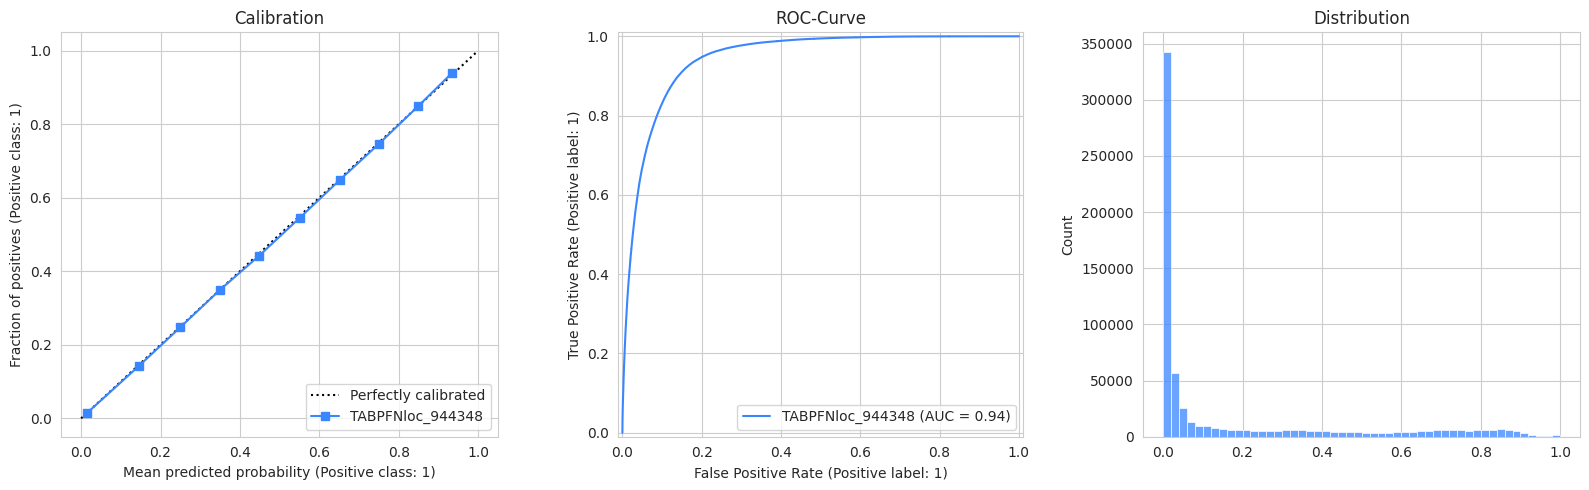

In [27]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for key_, val_ in v.items():
        if key_ == "oof_preds":
            ## -- Save oof predictions --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"oof_{n}.npy", val_)
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train_X[TARGET], val_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title(f"Calibration")

            RocCurveDisplay.from_predictions(train_X[TARGET], val_, name=n, ax=axs[1])
            axs[1].set_title(f"ROC-Curve")

            sns.histplot(val_, ax=axs[2], bins=50)
            axs[2].set_title(f"Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [28]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == "test_preds":
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submission[TARGET] = y
            submission.to_csv(f"submit_{n}.csv", index=False)
            print(f"{n} saved! {y.shape}")

            model_results[n[:-6]] = y

print()
model_results = pd.DataFrame(model_results)
model_results

TABPFNloc_944348 saved! (286571,)



,TABPFNloc_
0,0.016354
1,0.020515
2,0.004602
3,0.002533
4,0.025149
...,...
286566,0.000201
286567,0.254668
286568,0.000204
286569,0.000320


In [29]:
# !rm -r /kaggle/working